In [51]:
import pandas as pd
import praw
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import math
import numpy as np
import igraph as ig
import leidenalg
import pickle

reddit = praw.Reddit("project")
commentFrame = pd.read_pickle("comments.pkl")

variance = commentFrame["sentimentLabel"].var()
print(variance)

0.5365585200198384


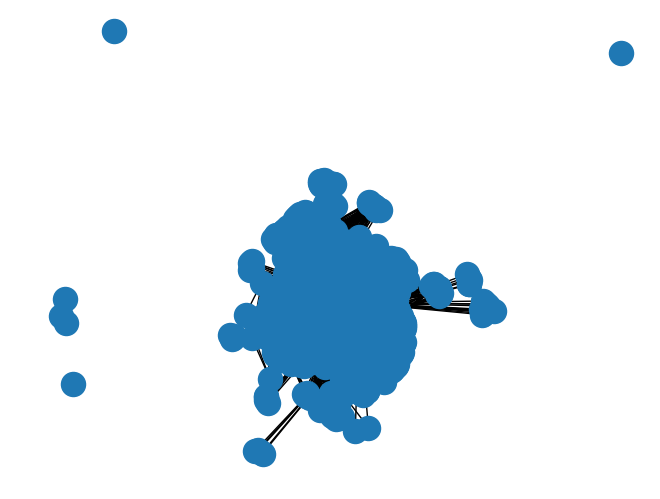

In [52]:
graph = nx.Graph()
graph.add_nodes_from(commentFrame["original post"].unique(), bipartite = 0)
graph.add_nodes_from(commentFrame["author"].unique(), bipartite = 1)#average weighted upvotes, average sentiment

author_upvotes = commentFrame.groupby("author")["upvoteScale"].mean().to_dict()

author_sentiment = (
    commentFrame.groupby("author")["AverageUserSentiment"].first().to_dict()
)

nx.set_node_attributes(graph, author_upvotes, "avg_upvotes")
nx.set_node_attributes(graph, author_sentiment, "avg_sentiment")
edges = zip(
    commentFrame["author"],
    commentFrame["original post"],
    commentFrame["body"],
    commentFrame["upvoteScale"]
)
graph.add_edges_from((a, b, {"body": c, "upvotes": d}) for a, b, c, d in edges)

uniqueUsers = [node for node, dic in graph.nodes(data = True) if dic["bipartite"] == 1]
biGraph = bipartite.weighted_projected_graph(graph, uniqueUsers)
nx.draw(biGraph)

In [53]:
print(biGraph.number_of_nodes())
print(biGraph.number_of_edges())
userGraph = biGraph.copy()
edges_to_remove = [(u,v) for u, v, d in biGraph.edges(data = True) if d["weight"] <= 1]
userGraph.remove_edges_from(edges_to_remove)

isolates = list(nx.isolates(userGraph))
userGraph.remove_nodes_from(isolates)
print(f"isolates:{len(list(nx.isolates(userGraph)))}")
print(f"nodes:{userGraph.number_of_nodes()}")
print(f"edges:{userGraph.number_of_edges()}")

4217
416105
isolates:0
nodes:599
edges:2659


In [54]:
fullGraph = nx.Graph()
fullGraph.add_nodes_from(userGraph)

for u, v, data in userGraph.edges(data = True):
    raw_weight = data.get("weight", 1)

    deg_u = userGraph.degree(u, weight = "weight")
    deg_v = userGraph.degree(v, weight  = "weight")
    normalized = raw_weight / math.sqrt(deg_u * deg_v) if deg_u > 0 and deg_v > 0 else 0
    fullGraph.add_edge(u, v, weight = normalized)


isolates = list(nx.isolates(fullGraph))
print("fullgraph stats")
print(f"nodes: {fullGraph.number_of_nodes()}")
print(f"isolates: {len(isolates)}")
print(f"edges: {userGraph.number_of_edges()}")

components = nx.connected_components(fullGraph)
giant_component = max(components, key = len)
G_Giant = fullGraph.subgraph(giant_component)
print("G_Giant stats")
print(G_Giant.number_of_nodes())
print(G_Giant.number_of_edges())

fullgraph stats
nodes: 599
isolates: 0
edges: 2659
G_Giant stats
540
2617


Num communities: 11
Community 0: [0, 2, 6, 9, 14, 16, 18, 20, 22, 24, 25, 26, 29, 30, 32, 33, 34, 35, 37, 39, 40, 41, 43, 49, 50, 59, 63, 72, 94, 99, 103, 132, 134, 136, 144, 172, 173, 174, 175, 176, 179, 180, 192, 253, 254, 258, 267, 275, 276, 316, 337, 338, 342, 343, 345, 373, 375, 376, 378, 379, 380, 381, 382, 383, 384, 386, 387, 398, 399, 400, 401, 402, 412, 415, 416, 418, 421, 445, 446, 451, 457, 460, 464, 466, 467, 468, 469, 470, 471, 473, 474, 475, 484, 502, 503, 504, 505, 506, 516, 517, 518, 519]
Community 1: [1, 5, 7, 42, 44, 45, 48, 104, 112, 115, 135, 137, 138, 141, 143, 151, 155, 156, 159, 170, 238, 239, 240, 241, 242, 243, 244, 245, 246, 251, 260, 266, 274, 277, 281, 285, 286, 352, 355, 358, 359, 360, 361, 363, 364, 365, 404, 425, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 438, 439, 440, 441, 442, 443, 444, 449, 478, 481, 485, 501, 534]
Community 2: [3, 4, 8, 11, 17, 21, 51, 52, 54, 74, 77, 82, 95, 96, 97, 102, 118, 119, 140, 157, 158, 160, 162, 164, 165, 167, 168, 

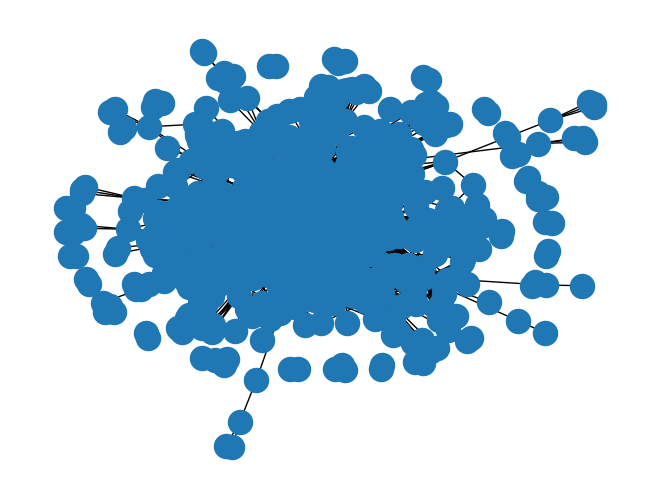

In [55]:
fullgraph = G_Giant.copy()
nodeList = list(fullgraph.nodes())
edges = [(nodeList.index(u), nodeList.index(v)) for u, v in fullgraph.edges()]

g = ig.Graph(edges = edges, directed = False)

if nx.get_edge_attributes(fullgraph, "weight"):
    g.es["weight"] = [fullgraph[u][v].get("weight", 1.0) for u, v in fullgraph.edges()]

partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

# Number of communities
print("Num communities:", len(partition))

# List nodes per community
for i, comm in enumerate(partition):
    print(f"Community {i}: {comm}")

# Modularity score
print("Modularity:", partition.quality())

with open("user_graph.pkl", "wb") as f:
    pickle.dump(fullGraph, f)
nx.draw(fullGraph)

In [56]:
G = userGraph.copy()
n = G.number_of_nodes()
percent = n/biGraph.number_of_nodes() * 100
m = G.number_of_edges()
density = nx.density(G)
components = list(nx.connected_components(G)) if not G.is_directed() else list(nx.weakly_connected_components(G))
num_components = len(components)
giant_size = max(len(c) for c in components) if components else 0
avg_degree = sum(dict(G.degree()).values())/n

print(f"nodes: {n}, edges: {m}, density: {density:.6f}, percent of nodes left after pruning: {percent:.2f}%")
print(f"components: {num_components}, giant component size: {giant_size}, avg degree: {avg_degree:.2f}")
# degree distribution quick view
deg_seq = sorted([d for _, d in G.degree()], reverse=True)
print("top degrees:", deg_seq[:10])

nodes: 599, edges: 2659, density: 0.014846, percent of nodes left after pruning: 14.20%
components: 26, giant component size: 540, avg degree: 8.88
top degrees: [134, 113, 99, 72, 67, 65, 62, 57, 57, 53]
